<a href="https://colab.research.google.com/github/mim-1999/customer-churn-prediction/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from getpass import getpass
token = getpass('Enter GitHub token: ')

username = 'mim-1999'
repo = 'customer-churn-prediction'

!git clone https://{token}@github.com/{username}/{repo}.git

Enter GitHub token: ··········
Cloning into 'customer-churn-prediction'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 23 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 170.24 KiB | 2.47 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [24]:
%cd customer-churn-prediction


/content/customer-churn-prediction


In [28]:
# import libraries
import os
os.makedirs('images', exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load dataset

In [3]:
import pandas as pd

url = 'https://raw.githubusercontent.com/mim-1999/customer-churn-prediction/main/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(url)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### TotalCharges is stored as an object dtype, not numeric — even though it's clearly meant to be a number.

In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
# convert TotalCharges to numeric and catch missing values
pd.to_numeric(df['TotalCharges'], errors='coerce').isnull().sum()

np.int64(11)

In [8]:
df[pd.to_numeric(df['TotalCharges'], errors='coerce').isnull()][['tenure', 'TotalCharges', 'Churn']]

,tenure,TotalCharges,Churn
488,0,,No
753,0,,No
936,0,,No
1082,0,,No
1340,0,,No
3331,0,,No
3826,0,,No
4380,0,,No
5218,0,,No
6670,0,,No


In [9]:
df.loc[[488,753,936,1082,1340,3331,3826,4380,5218,6670,6754], ['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


In [10]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].head(10)

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.5
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
5,8,99.65,820.5
6,22,89.10,1949.4
7,10,29.75,301.9
8,28,104.80,3046.05
9,62,56.15,3487.95


In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [12]:
df['TotalCharges'].dtype

dtype('float64')

In [13]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [14]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


In [15]:
df.groupby('Contract')['Churn'].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

In [16]:
df.groupby('PhoneService')['Churn'].value_counts(normalize=True)

PhoneService  Churn
No            No       0.750733
              Yes      0.249267
Yes           No       0.732904
              Yes      0.267096
Name: proportion, dtype: float64

In [19]:
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.569965
Yes,17.979133


In [20]:
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [21]:
# Create tenure bins
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['0-12 months', '12-24 months', '24-48 months', '48-72 months'])

# Churn rate per group
df.groupby('tenure_group')['Churn'].value_counts(normalize=True)

/tmp/ipykernel_3798/3818510478.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_group')['Churn'].value_counts(normalize=True)


tenure_group  Churn
0-12 months   No       0.523218
              Yes      0.476782
12-24 months  No       0.712891
              Yes      0.287109
24-48 months  No       0.796110
              Yes      0.203890
48-72 months  No       0.904868
              Yes      0.095132
Name: proportion, dtype: float64

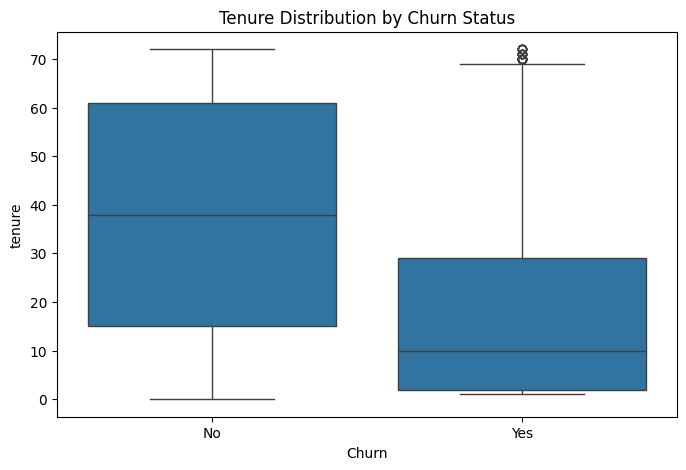

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure Distribution by Churn Status')
plt.savefig('images/tenure_by_churn.png')
plt.show()

In [27]:
df.groupby('Contract')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Contract,,,,,,,,
Month-to-month,3875.0,18.036645,17.689054,1.0,3.0,12.0,29.0,72.0
One year,1473.0,42.044807,19.035883,0.0,27.0,44.0,58.0,72.0
Two year,1695.0,56.735103,18.209363,0.0,48.0,64.0,71.0,72.0


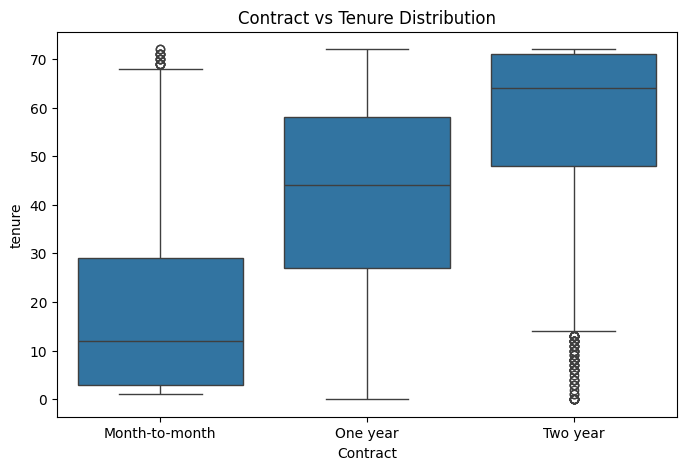

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Contract', y='tenure')
plt.title('Contract vs Tenure Distribution')
plt.savefig('images/Contract_vs_Tenure_Distribution.png')
plt.show()

#### As contract length increases, tenure increases right along with it.Contract type and tenure are telling a heavily overlapping story. Customers on month-to-month plans tend to be the newer customers (median 12 months). Contract type (huge effect) as (2 year reches toleaf node), tenure (strong effect, correlated with Contract).

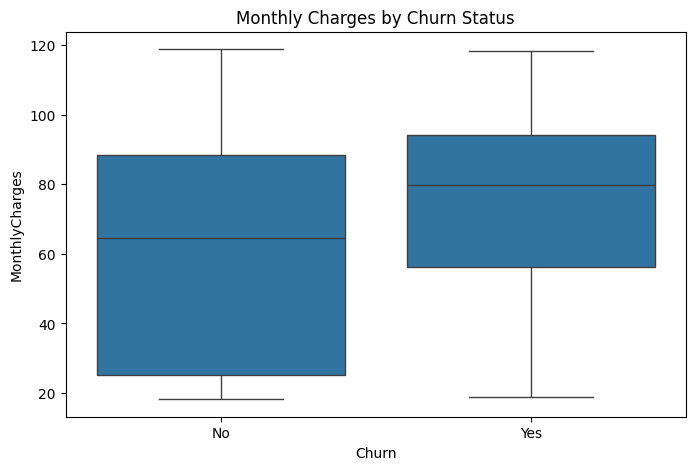

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn Status')
plt.savefig('images/Monthly_Charges_by_Churn_Status.png')
plt.show()


In [34]:
df.groupby('Contract')['MonthlyCharges'].median()

,MonthlyCharges
Contract,
Month-to-month,73.25
One year,68.75
Two year,64.35


## Key EDA Finding: Contract Type, Tenure, and Monthly Charges

Contract type, tenure, and MonthlyCharges are interrelated: newer, higher-paying,
month-to-month customers represent the highest-risk segment. Because these features
overlap in the signal they carry, we expect the decision tree to lean heavily on
whichever gives the highest Information Gain first (likely Contract), with the
others contributing comparatively less unique information deeper in the tree.